# Segunda Práctica: Determinación de tipos de estrellas

### Somos Lidia Valera López y Ana Díaz Jiménez del grupo 81
### Correos: 100522236@alumnos.uc3m.es y 100522155@alumnos.uc3m.es, respectivamente.
### NIAS: 100522236 y 100522155, respectivamente
### Nuestra semilla es la de la alumna Lidia Valera López

## 1. Codificación ordinal de variables categóricas


A continuación vamos a codificar las variables categóricas (color, clase espectral), teniendo en cuenta que el color está asociado a la cantidad de energía, y algo parecido con la clase espectral.

Lo primero que haremos es importar todas las librerias que vamos a necesitar en la práctica y establecer la semilla:

In [18]:
# Tratamiento de datos
import numpy as np
import pandas as pd

# Gráficos
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib import style
style.use('ggplot')

# Preprocesado
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram

# Reproducibilidad
SEED = 100522236
np.random.seed(SEED)

import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


También cargaremos los datos y los exploraremos:

In [19]:
# Cargamos el dataset
df = pd.read_csv('stars_data.csv')
print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (240, 6)


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
dtypes: float64(3), int64(1), str(2)
memory usage: 11.4 KB


In [21]:
df.describe()

,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


In [22]:
# Valores únicos en variables categóricas
print('Colores únicos:', sorted(df['Color'].unique()))
print('Clases espectrales únicas:', sorted(df['Spectral_Class'].unique()))

Colores únicos: ['Blue', 'Blue White', 'Blue white', 'Blue-White', 'Blue-white', 'Orange', 'Orange-Red', 'Pale yellow orange', 'Red', 'White', 'White-Yellow', 'Whitish', 'Yellowish', 'Yellowish White', 'white', 'yellow-white', 'yellowish']
Clases espectrales únicas: ['A', 'B', 'F', 'G', 'K', 'M', 'O']


Ahora codificaremos las variables categóricas, que son la clase Espectral y la clase Color, ya que están asociados a la temperatura y energía de la estrella y son strings.

-La clase espectral la codificaremos con una secuencia (de más caliente a más fría): O -> B -> A -> F -> G -> K -> M

-La clase color la codificaremos de azul a rojo, ya que el azul es como más energético y el rojo menos energético.

In [23]:
# Codificación ordinal de Clase Espectral 
spectral_order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df['Spectral_Class_enc'] = df['Spectral_Class'].map(spectral_order)

# Codificación ordinal de Color 
# Primero normalizamos el texto (strip + lower) para evitar problemas de formato
df['Color_clean'] = df['Color'].str.strip().str.lower()
print('Colores normalizados:', sorted(df['Color_clean'].unique()))

# Orden de colores de mayor temperatura (azul) a menor (rojo)
color_order = {
    'blue':              0,
    'blue-white':        1,
    'blue white':        1,
    'pale yellow orange':2,
    'white':             3,
    'whitish':           3,
    'yellowish white':   4,
    'yellow-white':      4,
    'white-yellow':      4,
    'yellow white':      4,
    'yellowish':         5,
    'orange':            6,
    'orange-red':        7,
    'red':               8,
}

df['Color_enc'] = df['Color_clean'].map(color_order)

# Comprobamos que no haya NaN (colores no mapeados)
unmapped = df[df['Color_enc'].isna()]['Color_clean'].unique()
if len(unmapped) > 0:
    print('⚠️  Colores sin mapear:', unmapped)
    # Asignar la mediana como valor por defecto para no perder filas
    df['Color_enc'].fillna(df['Color_enc'].median(), inplace=True)
else:
    print('Todos los colores han sido mapeados correctamente.')

df[['Color', 'Color_enc', 'Spectral_Class', 'Spectral_Class_enc']].head(10)

Colores normalizados: ['blue', 'blue white', 'blue-white', 'orange', 'orange-red', 'pale yellow orange', 'red', 'white', 'white-yellow', 'whitish', 'yellow-white', 'yellowish', 'yellowish white']
Todos los colores han sido mapeados correctamente.


,Color,Color_enc,Spectral_Class,Spectral_Class_enc
0,Red,8,M,6
1,Red,8,M,6
2,Red,8,M,6
3,Red,8,M,6
4,Red,8,M,6
5,Red,8,M,6
6,Red,8,M,6
7,Red,8,M,6
8,Red,8,M,6
9,Red,8,M,6


In [24]:
# Dataset final con variables numéricas para el modelado
features = ['Temperature', 'L', 'R', 'A_M', 'Color_enc', 'Spectral_Class_enc']
X = df[features].copy()
print('Features seleccionadas:', features)
X.describe()

Features seleccionadas: ['Temperature', 'L', 'R', 'A_M', 'Color_enc', 'Spectral_Class_enc']


,Temperature,L,R,A_M,Color_enc,Spectral_Class_enc
count,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,4.404167,3.479167
std,9552.425037,179432.244940,517.155763,10.532512,3.574547,2.531720
min,1939.000000,0.000080,0.008400,-11.920000,0.000000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,4.000000,3.000000
75%,15055.500000,198050.000000,42.750000,13.697500,8.000000,6.000000
max,40000.000000,849420.000000,1948.500000,20.060000,8.000000,6.000000


## 2. Reducción dimensional con PCA (2 componentes)

Antes del clustering se aplica PCA para facilitar la visualización y mejorar la tarea de clustering (agrupamiento).

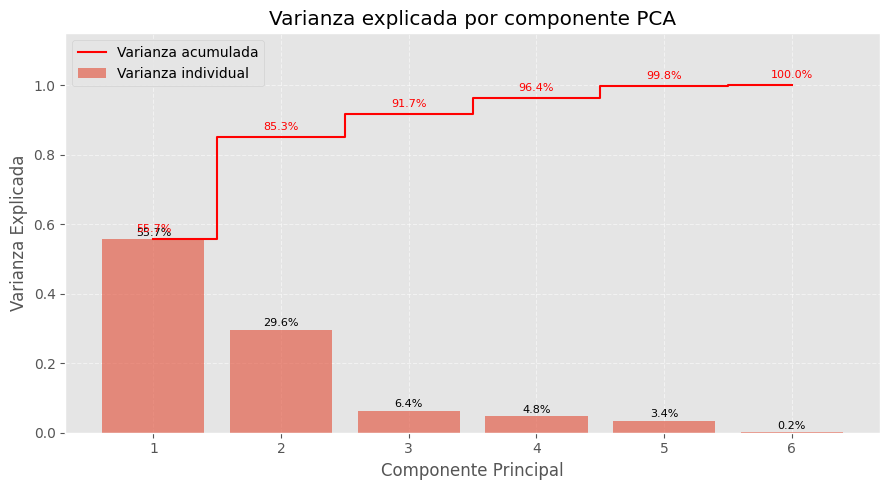

In [25]:
# Varianza explicada con todos los componentes
pipeline_full = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(random_state=SEED))
])
pipeline_full.fit(X)
pca_full = pipeline_full.named_steps['pca']

explained_var   = pca_full.explained_variance_ratio_
cumulative_var  = np.cumsum(explained_var)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, label='Varianza individual')
ax.step(range(1, len(cumulative_var)+1), cumulative_var, where='mid',
        color='red', label='Varianza acumulada')

for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    ax.text(i+1, ev+0.01, f'{ev:.1%}', ha='center', fontsize=8)
    ax.text(i+1, cv+0.02, f'{cv:.1%}', ha='center', fontsize=8, color='red')

ax.set_xlabel('Componente Principal')
ax.set_ylabel('Varianza Explicada')
ax.set_title('Varianza explicada por componente PCA')
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Varianza explicada PC1: 55.69%
Varianza explicada PC2: 29.60%
Varianza total explicada: 85.29%


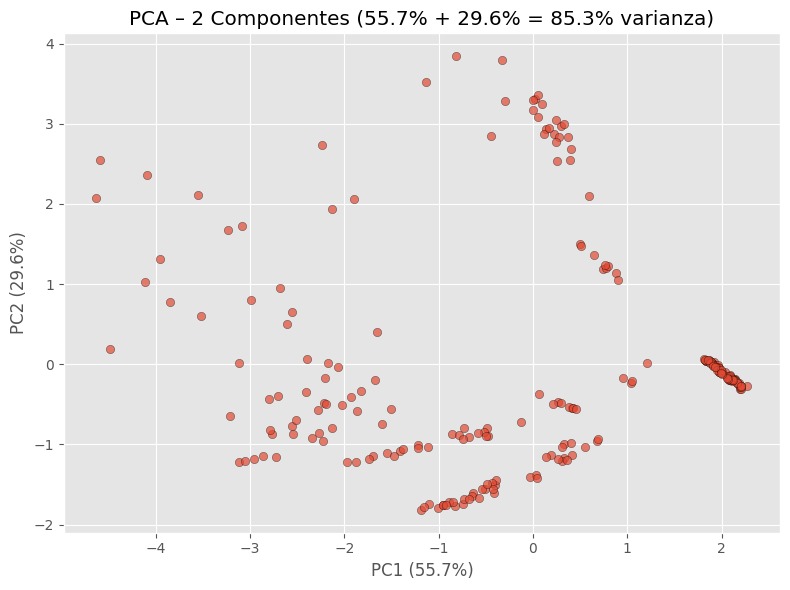

In [26]:
#  PCA con 2 componentes (pipeline final para el clustering) 
pipeline_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=2, random_state=SEED))
])

X_pca = pipeline_pca.fit_transform(X)
pca2  = pipeline_pca.named_steps['pca']

var1 = pca2.explained_variance_ratio_[0]
var2 = pca2.explained_variance_ratio_[1]

print(f'Varianza explicada PC1: {var1:.2%}')
print(f'Varianza explicada PC2: {var2:.2%}')
print(f'Varianza total explicada: {var1+var2:.2%}')

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, edgecolors='k', linewidths=0.3)
ax.set_title(f'PCA – 2 Componentes ({var1:.1%} + {var2:.1%} = {var1+var2:.1%} varianza)')
ax.set_xlabel(f'PC1 ({var1:.1%})')
ax.set_ylabel(f'PC2 ({var2:.1%})')
plt.tight_layout()
plt.show()

## 3. K-Means, Hierarchical Clustering/Dendrogramas y DBSCAN

A continuación aplicaremos los tres algoritmos de clustering que nos han explicado en clase y compararemos y discutiremos los resultados que se obtienen de ellos.

### 3.1. K-Means

### 3.2. Hierarchical Clustering/Dendrogramas

### 3.3. DBSCAN

## 4. ¿Cuál es más recomendable usar?

A continuación analizaremos los resultados obtenidos en el anterior punto y elegiremos que pipeline de clustering, algoritmo, con sus hiperparámetros, recomendaríamos realizar.

## 5. Similitudes entre las clases de la tabla y los obtenidos en el punto 4

A partir de la tabla del enunciado de la práctica que contiene las clases y atributos asociados a las estrellas de la astonomía utiliza hambitualmente, comprobaremos y explicaremos si hay similitudes entre estas clases y los grupos obtenidos en el punto 4.